# 🔍 Customer Churn Prediction
## Phase 1 — Exploratory Data Analysis (EDA)

| Detail | Info |
|---|---|
| **Dataset** | IBM Telco Customer Churn |
| **Rows** | 7,043 customers |
| **Features** | 21 columns |
| **Target** | Churn (Yes / No) |
| **Author** | Shubham Kumar |
| **Tool** | Python · Pandas · Seaborn · Plotly |

### Objective
Understand the dataset structure, identify missing values,
analyse churn patterns, and extract business insights
before moving to feature engineering and modelling.

---
## 1. Environment Setup
*Installing and importing all required libraries*

In [1]:
# ================================================================
# SECTION 1 : ENVIRONMENT SETUP
# ================================================================

!pip install xgboost shap imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("=" * 50)
print("  All libraries loaded successfully!")
print("=" * 50)

  All libraries loaded successfully!


---
## 2. Data Loading
*Loading IBM Telco dataset directly from URL and doing first look*

In [2]:
# ================================================================
# SECTION 2 : DATA LOADING
# ================================================================

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("=" * 50)
print("  Dataset Loaded Successfully!")
print("=" * 50)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print("=" * 50)

  Dataset Loaded Successfully!
  Rows    : 7043
  Columns : 21


---
## 3. First Look at Data
*Understanding structure — column names, data types, sample rows*

In [3]:
# ================================================================
# SECTION 3 : FIRST LOOK AT DATA
# ================================================================

# 3.1 First 5 rows
print("--- 3.1 First 5 Rows ---")
display(df.head())

# 3.2 Column names and data types
print("\n--- 3.2 Column Names & Data Types ---")
print(df.dtypes)

# 3.3 Dataset shape
print(f"\n--- 3.3 Shape ---")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# 3.4 Basic statistics
print("\n--- 3.4 Basic Statistics ---")
display(df.describe())

--- 3.1 First 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- 3.2 Column Names & Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- 3.3 Shape ---
Rows    : 7043
Columns : 21

--- 3.4 Basic Statistics ---


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---
## 4. Data Quality Check
*Checking missing values, duplicates and data issues*

In [4]:
# ================================================================
# SECTION 4 : DATA QUALITY CHECK
# ================================================================

# 4.1 Missing values
print("--- 4.1 Missing Values ---")
missing = pd.DataFrame({
    'Column'        : df.columns,
    'Missing Count' : df.isnull().sum().values,
    'Missing %'     : (df.isnull().sum().values / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0]
if len(missing) == 0:
    print("No missing values found!")
else:
    display(missing)

# 4.2 Duplicate rows
print(f"\n--- 4.2 Duplicate Rows ---")
print(f"Duplicate rows : {df.duplicated().sum()}")

# 4.3 TotalCharges hidden issue
print(f"\n--- 4.3 TotalCharges Data Type Issue ---")
print(f"TotalCharges dtype : {df['TotalCharges'].dtype}")
print(f"Sample values      : {df['TotalCharges'].head(10).tolist()}")

# 4.4 Fix TotalCharges — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 4.5 Check missing after conversion
print(f"\n--- 4.4 Missing in TotalCharges After Fix ---")
print(f"Missing values : {df['TotalCharges'].isnull().sum()}")

# 4.6 Fill missing with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print(f"Missing after fill : {df['TotalCharges'].isnull().sum()}")

print("\n" + "=" * 50)
print("  Data Quality Check Complete!")
print("=" * 50)

--- 4.1 Missing Values ---
No missing values found!

--- 4.2 Duplicate Rows ---
Duplicate rows : 0

--- 4.3 TotalCharges Data Type Issue ---
TotalCharges dtype : object
Sample values      : ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']

--- 4.4 Missing in TotalCharges After Fix ---
Missing values : 11
Missing after fill : 0

  Data Quality Check Complete!


---
## 5. Churn Distribution Analysis
*How many customers churned? Understanding our target variable*

--- 5.1 Churn Count ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate : 26.54%


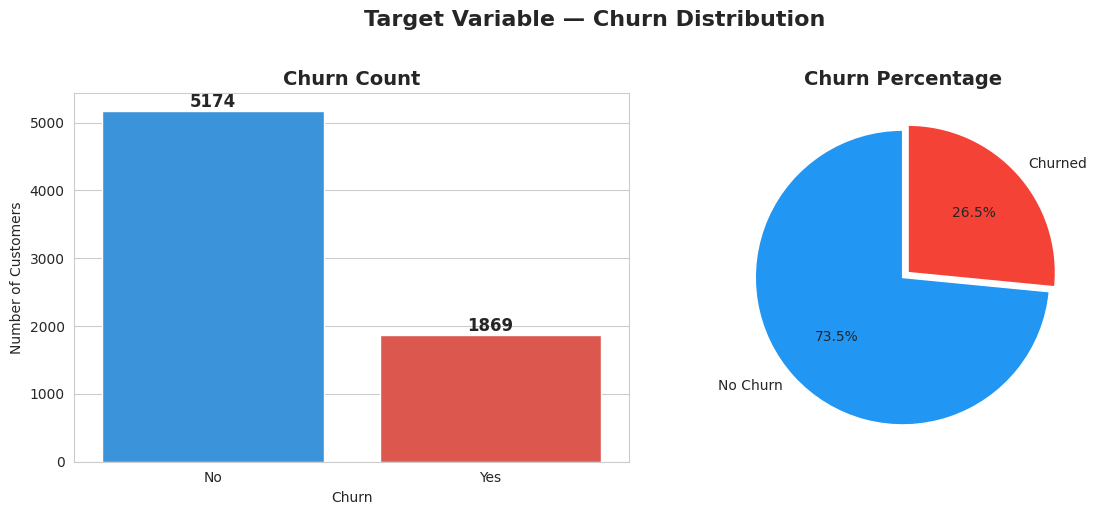


--- Business Insight ---
  Total Customers   : 7043
  Churned           : 1869
  Not Churned       : 5174
  Churn Rate        : 26.54%
  Class Imbalance   : YES — will handle with SMOTE in modelling phase


In [5]:
# ================================================================
# SECTION 5 : CHURN DISTRIBUTION ANALYSIS
# ================================================================

# 5.1 Churn count
print("--- 5.1 Churn Count ---")
print(df['Churn'].value_counts())
print(f"\nChurn Rate : {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

# 5.2 Churn count plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='Churn', palette=['#2196F3','#F44336'], ax=axes[0])
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts,
            labels=['No Churn', 'Churned'],
            autopct='%1.1f%%',
            colors=['#2196F3','#F44336'],
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable — Churn Distribution',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Business Insight ---")
print(f"  Total Customers   : {len(df)}")
print(f"  Churned           : {df['Churn'].value_counts()['Yes']}")
print(f"  Not Churned       : {df['Churn'].value_counts()['No']}")
print(f"  Churn Rate        : 26.54%")
print(f"  Class Imbalance   : YES — will handle with SMOTE in modelling phase")

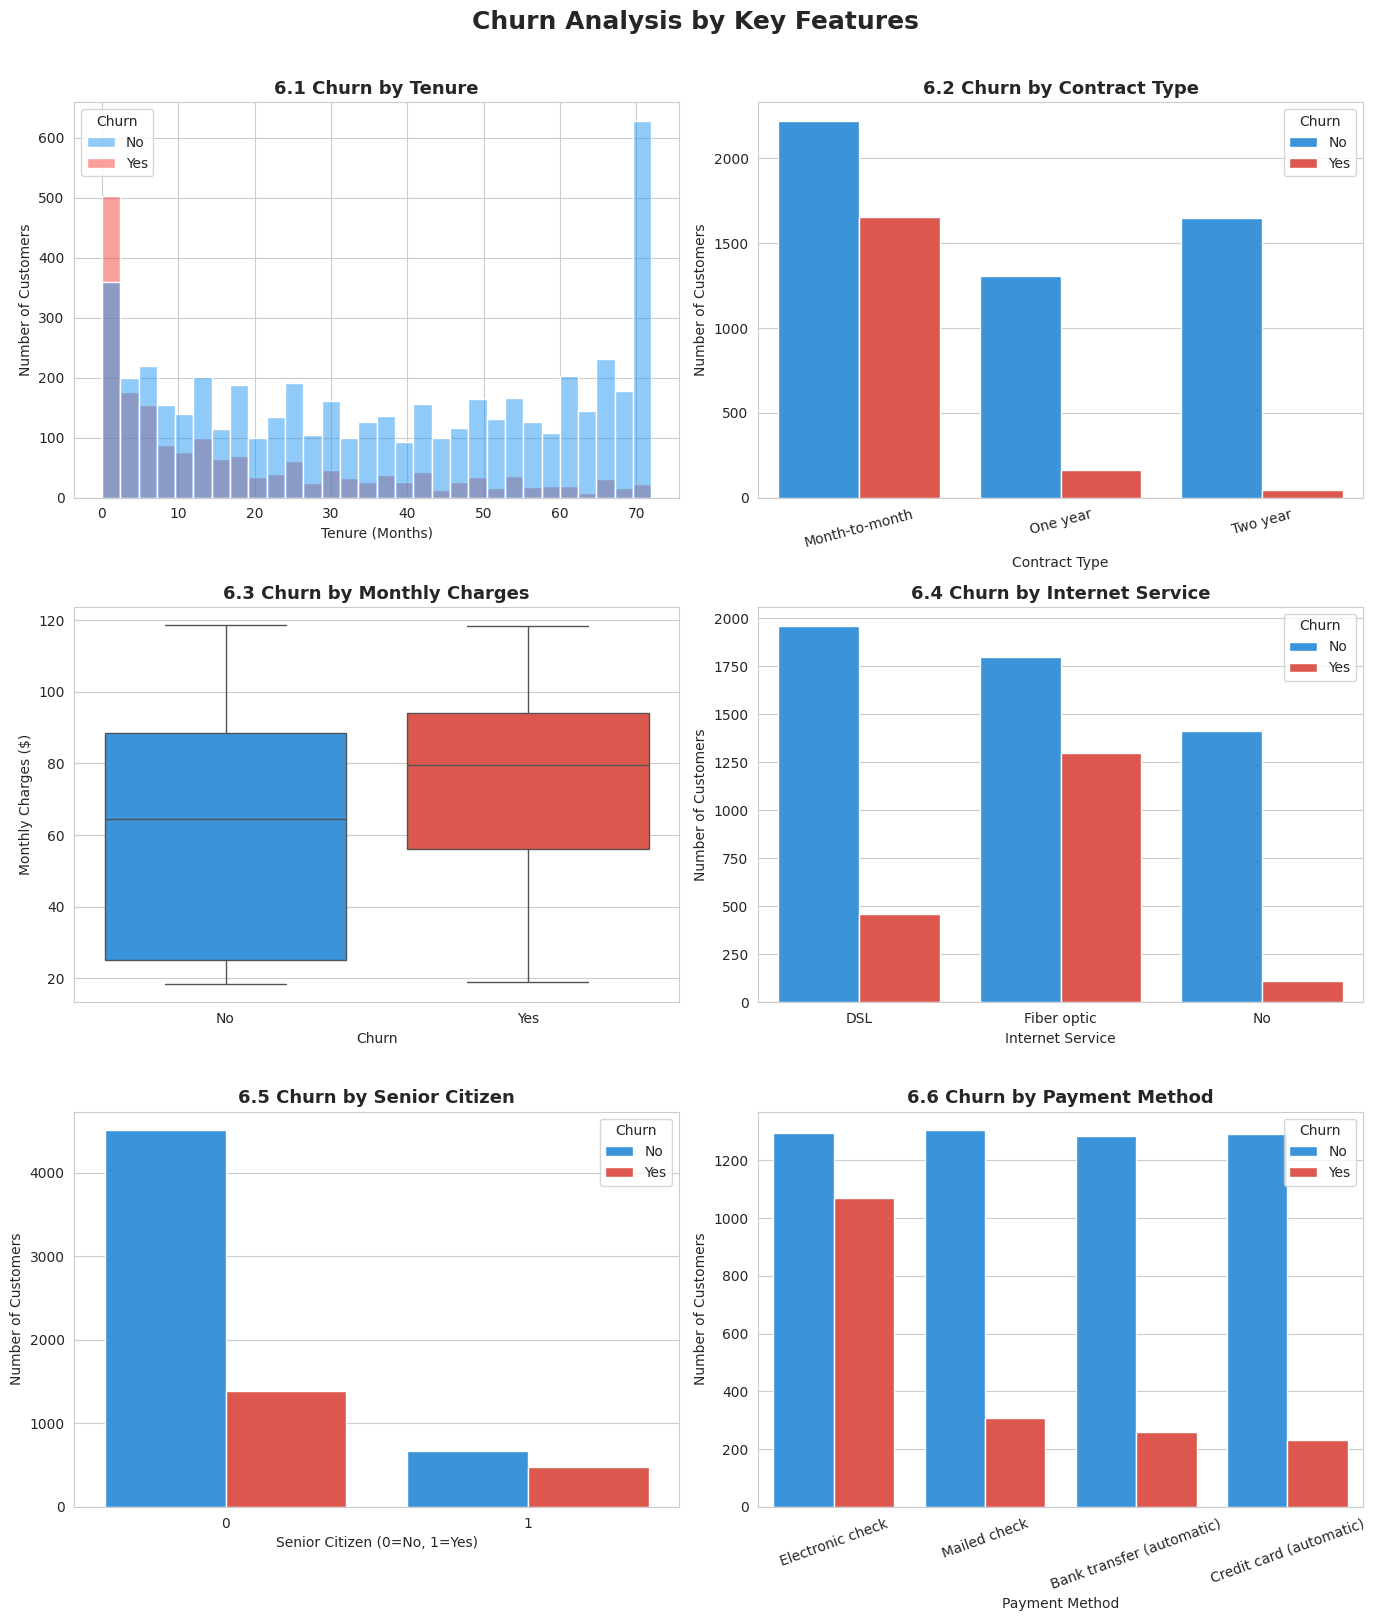

  BUSINESS INSIGHTS FROM CHURN ANALYSIS
  6.1 Tenure       : Customers with tenure < 12 months
                     churn the most. Long tenure = loyal.
  6.2 Contract     : Month-to-month customers churn most.
                     2-year contract = very low churn.
  6.3 Monthly Bill : Churned customers pay higher bills.
                     High charge + bad service = exit.
  6.4 Internet     : Fibre optic customers churn most
                     despite paying premium price.
  6.5 Senior       : Senior citizens churn more than
                     non-senior customers.
  6.6 Payment      : Electronic check users churn most.


In [7]:
# ================================================================
# SECTION 6 : CHURN ANALYSIS BY KEY FEATURES
# ================================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Churn Analysis by Key Features',
             fontsize=18, fontweight='bold', y=1.01)

# ----------------------------------------------------------------
# 6.1 Churn by Tenure
# ----------------------------------------------------------------
axes[0, 0].set_title('6.1 Churn by Tenure', fontsize=13, fontweight='bold')
sns.histplot(data=df, x='tenure', hue='Churn',
             palette=['#2196F3','#F44336'],
             bins=30, ax=axes[0, 0])
axes[0, 0].set_xlabel('Tenure (Months)')
axes[0, 0].set_ylabel('Number of Customers')

# ----------------------------------------------------------------
# 6.2 Churn by Contract Type
# ----------------------------------------------------------------
axes[0, 1].set_title('6.2 Churn by Contract Type', fontsize=13, fontweight='bold')
sns.countplot(data=df, x='Contract', hue='Churn',
              palette=['#2196F3','#F44336'], ax=axes[0, 1])
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].tick_params(axis='x', rotation=15)

# ----------------------------------------------------------------
# 6.3 Churn by Monthly Charges
# ----------------------------------------------------------------
axes[1, 0].set_title('6.3 Churn by Monthly Charges', fontsize=13, fontweight='bold')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette=['#2196F3','#F44336'], ax=axes[1, 0])
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Monthly Charges ($)')

# ----------------------------------------------------------------
# 6.4 Churn by Internet Service
# ----------------------------------------------------------------
axes[1, 1].set_title('6.4 Churn by Internet Service', fontsize=13, fontweight='bold')
sns.countplot(data=df, x='InternetService', hue='Churn',
              palette=['#2196F3','#F44336'], ax=axes[1, 1])
axes[1, 1].set_xlabel('Internet Service')
axes[1, 1].set_ylabel('Number of Customers')

# ----------------------------------------------------------------
# 6.5 Churn by Senior Citizen
# ----------------------------------------------------------------
axes[2, 0].set_title('6.5 Churn by Senior Citizen', fontsize=13, fontweight='bold')
sns.countplot(data=df, x='SeniorCitizen', hue='Churn',
              palette=['#2196F3','#F44336'], ax=axes[2, 0])
axes[2, 0].set_xlabel('Senior Citizen (0=No, 1=Yes)')
axes[2, 0].set_ylabel('Number of Customers')

# ----------------------------------------------------------------
# 6.6 Churn by Payment Method
# ----------------------------------------------------------------
axes[2, 1].set_title('6.6 Churn by Payment Method', fontsize=13, fontweight='bold')
sns.countplot(data=df, x='PaymentMethod', hue='Churn',
              palette=['#2196F3','#F44336'], ax=axes[2, 1])
axes[2, 1].set_xlabel('Payment Method')
axes[2, 1].set_ylabel('Number of Customers')
axes[2, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('churn_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------
# Business Insights
# ----------------------------------------------------------------
print("=" * 55)
print("  BUSINESS INSIGHTS FROM CHURN ANALYSIS")
print("=" * 55)
print("  6.1 Tenure       : Customers with tenure < 12 months")
print("                     churn the most. Long tenure = loyal.")
print("  6.2 Contract     : Month-to-month customers churn most.")
print("                     2-year contract = very low churn.")
print("  6.3 Monthly Bill : Churned customers pay higher bills.")
print("                     High charge + bad service = exit.")
print("  6.4 Internet     : Fibre optic customers churn most")
print("                     despite paying premium price.")
print("  6.5 Senior       : Senior citizens churn more than")
print("                     non-senior customers.")
print("  6.6 Payment      : Electronic check users churn most.")
print("=" * 55)

---
## 7. Correlation Heatmap
*Which numerical features are most correlated with each other?*

--- Numerical Columns ---
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


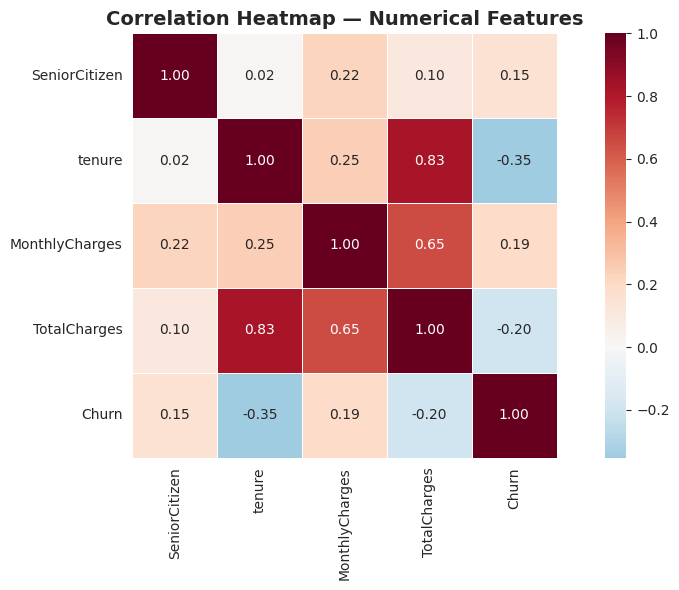


--- Correlation with Churn (High to Low) ---
Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199037
tenure           -0.352229
Name: Churn, dtype: float64

--- Business Insight ---
  Tenure         : Negative correlation with churn
                   Longer tenure = less likely to churn
  MonthlyCharges : Positive correlation with churn
                   Higher bill = more likely to churn
  TotalCharges   : Negative correlation with churn
                   High total = long customer = loyal


In [23]:
# ================================================================
# SECTION 7 : CORRELATION HEATMAP
# ================================================================

# 7.1 Encode target for correlation
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# 7.2 Select only numerical columns
numerical_cols = df_corr.select_dtypes(include=['int64',
                                                'float64']).columns
print("--- Numerical Columns ---")
print(numerical_cols.tolist())

# 7.3 Correlation matrix
corr_matrix = df_corr[numerical_cols].corr()

# 7.4 Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 7.5 Churn correlation specifically
print("\n--- Correlation with Churn (High to Low) ---")
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

print("\n--- Business Insight ---")
print("  Tenure         : Negative correlation with churn")
print("                   Longer tenure = less likely to churn")
print("  MonthlyCharges : Positive correlation with churn")
print("                   Higher bill = more likely to churn")
print("  TotalCharges   : Negative correlation with churn")
print("                   High total = long customer = loyal")

---
## 8. EDA Summary
*Key findings and business insights from Exploratory Data Analysis*

In [24]:
# ================================================================
# SECTION 8 : EDA SUMMARY
# ================================================================

print("=" * 60)
print("        EDA SUMMARY — CUSTOMER CHURN ANALYSIS")
print("=" * 60)

print("""
DATASET OVERVIEW
----------------------------------------------------------------
Total Customers    : 7,043
Total Features     : 21 (demographics, account, services)
Target Variable    : Churn (Yes = 1 / No = 0)
Churn Rate         : 26.54% (imbalanced dataset)
Missing Values     : 11 in TotalCharges (fixed with median)
Duplicates         : 0

----------------------------------------------------------------
KEY FINDINGS FROM EDA
----------------------------------------------------------------

FINDING 1 — TENURE
  Chart        : Section 6.1 Histplot
  Observation  : Customers with tenure 0-12 months
                 churn the most
  Insight      : New customers are highest risk
  Action       : Focus retention on first 12 months

FINDING 2 — CONTRACT TYPE
  Chart        : Section 6.2 Countplot
  Observation  : Month-to-month customers churn most
                 2-year contract customers rarely churn
  Insight      : Long term contracts = loyal customers
  Action       : Offer discounts to switch to annual plans

FINDING 3 — MONTHLY CHARGES
  Chart        : Section 6.3 Boxplot
  Observation  : Churned customers pay higher monthly bills
                 Median bill of churned = ~$80
                 Median bill of loyal   = ~$65
  Insight      : High bill + any service issue = exit
  Action       : Review pricing for high-paying customers

FINDING 4 — INTERNET SERVICE
  Chart        : Section 6.4 Countplot
  Observation  : Fibre optic customers churn most
                 despite paying premium price
  Insight      : Service quality not matching price
  Action       : Improve fibre optic service quality

FINDING 5 — PAYMENT METHOD
  Chart        : Section 6.6 Countplot
  Observation  : Electronic check users churn most
  Insight      : Manual payment = less committed customer
  Action       : Encourage auto-pay enrollment

FINDING 6 — CORRELATION
  Chart        : Section 7 Heatmap
  Observation  : Tenure  negatively correlated (-0.35)
                 Monthly charges positively correlated (+0.19)
  Insight      : Confirms findings from individual charts

----------------------------------------------------------------
TOP 3 CHURN RISK PROFILE
----------------------------------------------------------------
  A customer is HIGH RISK if they have:
  1. Tenure        < 12 months
  2. Contract      = Month-to-month
  3. Monthly bill  > $65

----------------------------------------------------------------
WHAT WE DO NEXT
----------------------------------------------------------------
  Notebook 2 → Feature Engineering
               Encode categories
               Scale numerical features
               Create new features
               RFM Customer Segmentation

  Notebook 3 → Model Training
               Train 4 models
               Compare F1 scores
               Select best model
               Handle imbalance with SMOTE
""")

print("=" * 60)
print("        END OF EDA — NOTEBOOK 1 COMPLETE!")
print("=" * 60)

        EDA SUMMARY — CUSTOMER CHURN ANALYSIS

DATASET OVERVIEW
----------------------------------------------------------------
Total Customers    : 7,043
Total Features     : 21 (demographics, account, services)
Target Variable    : Churn (Yes = 1 / No = 0)
Churn Rate         : 26.54% (imbalanced dataset)
Missing Values     : 11 in TotalCharges (fixed with median)
Duplicates         : 0

----------------------------------------------------------------
KEY FINDINGS FROM EDA
----------------------------------------------------------------

FINDING 1 — TENURE
  Chart        : Section 6.1 Histplot
  Observation  : Customers with tenure 0-12 months
                 churn the most
  Insight      : New customers are highest risk
  Action       : Focus retention on first 12 months

FINDING 2 — CONTRACT TYPE
  Chart        : Section 6.2 Countplot
  Observation  : Month-to-month customers churn most
                 2-year contract customers rarely churn
  Insight      : Long term contracts = 